In [9]:
!pip install langchain langchain-community langchain-huggingface pypdf faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.6/329.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.9 MB/s eta 0:00:00


In [14]:
!pip install -U langchain-text-splitters

In [3]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

**loading our pdf **

In [4]:
loader=PyPDFLoader("/content/Medical_book .pdf")

In [5]:
pages=loader.load()

In [6]:
len(pages)

637

In [7]:
pages[:10]

[Document(metadata={'producer': 'PDFlib+PDI 5.0.0 (SunOS)', 'creator': 'PyPDF', 'creationdate': '2004-12-18T17:00:02-05:00', 'moddate': '2004-12-18T16:15:31-06:00', 'source': '/content/Medical_book .pdf', 'total_pages': 637, 'page': 0, 'page_label': '1'}, page_content=''),
 Document(metadata={'producer': 'PDFlib+PDI 5.0.0 (SunOS)', 'creator': 'PyPDF', 'creationdate': '2004-12-18T17:00:02-05:00', 'moddate': '2004-12-18T16:15:31-06:00', 'source': '/content/Medical_book .pdf', 'total_pages': 637, 'page': 1, 'page_label': '2'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION'),
 Document(metadata={'producer': 'PDFlib+PDI 5.0.0 (SunOS)', 'creator': 'PyPDF', 'creationdate': '2004-12-18T17:00:02-05:00', 'moddate': '2004-12-18T16:15:31-06:00', 'source': '/content/Medical_book .pdf', 'total_pages': 637, 'page': 2, 'page_label': '3'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION\nJACQUELINE L. LONGE, EDITOR\nDEIRDRE S. BLANCHFIELD, ASSOCIATE EDITOR\nVOLUME\

***There is a lot of irrelevant metadata, so we remove it and keep only the source in metadata along with the page content***

In [8]:
from langchain_core.documents import Document

In [10]:
cleaned_docs = []

for doc in pages:
    new_metadata = {
        "source": doc.metadata.get('source')
    }

    new_doc = Document(
        page_content=doc.page_content,
        metadata=new_metadata
    )

    cleaned_docs.append(new_doc)

In [11]:
cleaned_docs[:10]

[Document(metadata={'source': '/content/Medical_book .pdf'}, page_content=''),
 Document(metadata={'source': '/content/Medical_book .pdf'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION'),
 Document(metadata={'source': '/content/Medical_book .pdf'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION\nJACQUELINE L. LONGE, EDITOR\nDEIRDRE S. BLANCHFIELD, ASSOCIATE EDITOR\nVOLUME\nA-B\n1'),
 Document(metadata={'source': '/content/Medical_book .pdf'}, page_content='STAFF\nJacqueline L. Longe, Project Editor\nDeirdre S. Blanchfield, Associate Editor\nChristine B. Jeryan, Managing Editor\nDonna Olendorf, Senior Editor\nStacey Blachford, Associate Editor\nKate Kretschmann, Melissa C. McDade, Ryan\nThomason, Assistant Editors\nMark Springer, Technical Specialist\nAndrea Lopeman, Programmer/Analyst\nBarbara J. Yarrow,Manager, Imaging and Multimedia\nContent\nRobyn V . Young,Project Manager, Imaging and\nMultimedia Content\nDean Dauphinais, Senior Editor, Imagi

In [13]:
len(cleaned_docs)

637

In [14]:
cleaned_docs = [doc for doc in cleaned_docs if doc.page_content.strip()]

In [15]:
len(cleaned_docs)

636

**We now split the cleaned documents into smaller chunks.  
this is necessary because:
LLM have limited context windows
large pages are hard to process at once
 smaller chunks improve embedding quality and retrieval accuracy in RAG
this makes the data easier for the LLM to understand and process effectively.**

In [16]:
text_splitter =RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=20
)

In [17]:
chunks=text_splitter.split_documents(cleaned_docs)

In [18]:
len(chunks)

5859

**Now we will convert our chunks into embeddings using Sentence Transformers.
This step creates dense vector representations of each chunk, enabling efficient similarity search and better retrieval in the RAG pipeline.**

In [57]:
!pip install -U langchain-chroma chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:

In [19]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

In [20]:
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

In [22]:
vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory="./chroma_db" )

In [30]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [32]:
query = "What are the symptoms of diabetes?"
retrieved_docs = retriever.invoke(query)
print(retrieved_docs[0].page_content)

• Type I diabetes mellitus. Characterized by fatigue and
an abnormally high level of glucose in the blood
(hyperglycemia).
• Amyotrophic lateral schlerosis. First signs are stum-
bling and difficulty climbing stairs. Later, muscle
cramps and twitching may be observed as well as
weakness in the hands making fastening buttons or
turning a key difficult. Speech may become slowed or
slurred. There may also be difficluty swallowing. As
respiratory muscles atrophy, there is increased danger


In [28]:
!pip install -U langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.6/426.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.43.0
    Uninstalling google-auth-2.43.0:
      Successfully uninstalled google-auth-2.43.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.55.0
    Uninstalling google-genai-1.55.0:
      Successfully uninstalled google-genai-1.55.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.45.0 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, b

In [48]:
!pip install -U langchain-classic

In [50]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

In [61]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash",
    google_api_key="enter your api key"
)

In [52]:
system_prompt = (
    "You are a helpful medical assistant. "
    "Use the retrieved context to answer the user's question accurately. "
    "If the question asks for a list (like symptoms, causes, or treatments), use bullet points for clarity. "
    "If the answer is not in the context, say you don't know. "
    "Keep the language simple and avoid complex medical jargon where possible."
    "\n\n"
    "{context}"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}"),
    ]
)

In [53]:
question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

## testing


In [57]:
user_question = "What are the symptoms of Diabetes?"
response = rag_chain.invoke({"input": user_question})
print(response["answer"])

The symptoms of Diabetes mentioned in the context are:

*   Fatigue
*   An abnormally high level of glucose in the blood (hyperglycemia)


**lets ask some related question from this pdf page**

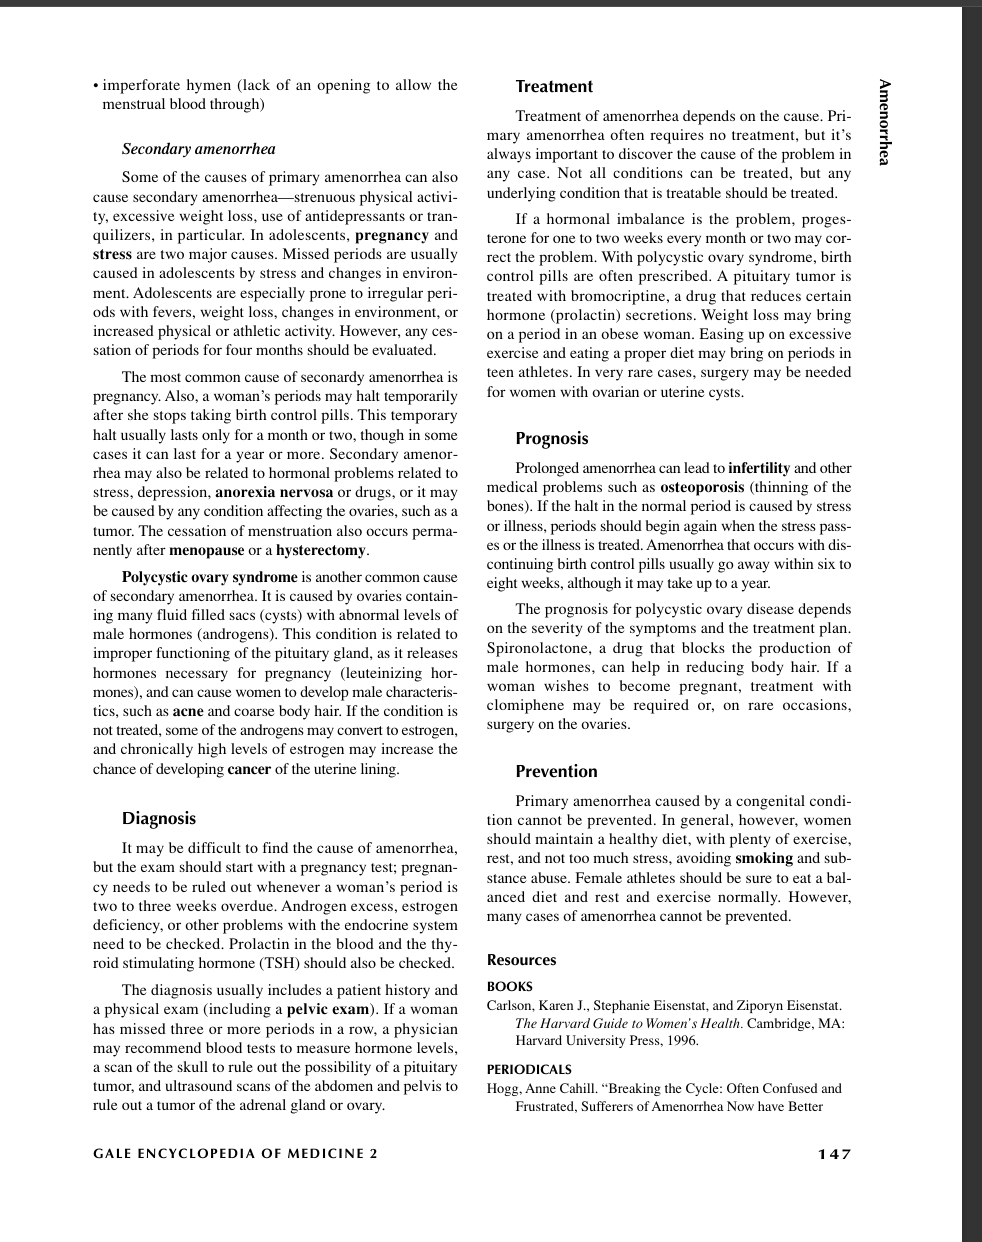

In [58]:
user_question = "What is amenorrhea?"
response = rag_chain.invoke({"input": user_question})
print(response["answer"])

Amenorrhea is the absence of menstrual periods.

It can be:
*   **Primary amenorrhea:** When a period has not started by the age of 16.
*   **Secondary amenorrhea:** When periods stop temporarily or permanently in a woman who previously had them. This occurs if a woman misses three or more periods in a row.


In [60]:
user_question = "Explain polycystic ovary syndrome, including its hormonal effects and complications."
response = rag_chain.invoke({"input": user_question})
print(response["answer"])

Polycystic ovary syndrome is a condition where the ovaries contain many fluid-filled sacs (cysts).

**Hormonal effects:**
*   It causes abnormal levels of male hormones (androgens).

**Complications:**
The provided context does not explicitly list complications. However, it does indicate that if a woman wishes to become pregnant, treatment with clomiphene or, in rare cases, surgery on the ovaries may be required.
